# Wastewater Monitoring and COVID-19 Trends

**Dataset:** `biobot_kits_quant_data_duvalletetal2022.csv` (in this `SARS-CoV2` folder)

### Notebook goals
In this notebook, students will:
- explore a cleaned wastewater surveillance dataset
- learn what each selected column means
- build two time-series plots step by step
- compare wastewater concentration trends to reported case trends
- use a simple regression model to test how wastewater measurements might relate to case counts

---

### Instructor intro placeholder
**Add instructor blurb here.**

> Replace this text with the short introduction your professor sends later.

### Video placeholder
**Video title:** `[add title here]`

Paste an embed link or video note here later.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, YouTubeVideo
import ipywidgets as widgets

from backend_data import (
    load_and_clean_wastewater_data,
    show_column_blurb_widget,
    plot_overlay_for_label,
    prepare_regression_model,
    explain_regression_for_students,
    plot_regression_fit,
    explain_regression_plot_for_students,
    show_interactive_prediction_widget,
)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

df, raw_path, clean_path = load_and_clean_wastewater_data(save_cleaned=True)
print("Loaded raw file:", raw_path)
print("Cleaned dataset shape:", df.shape)
print("Saved cleaned file as:", clean_path)
df.head()


Loaded raw file: biobot_kits_quant_data_duvalletetal2022.csv
Cleaned dataset shape: (2723, 7)
Saved cleaned file as: cleaned_wastewater_covid_data.csv


,sampling_date,normalized_conc_copies_per_L,pmmv_copies_per_mL_kit_raw,sarscov2_copies_per_mL_kit_raw,rolling_average_new_cases_centered,fig1_label,sars_to_pmmv_ratio
0,2020-04-22,1.117106e+06,7.842528e+04,240.025598,14.285714,A1,0.003061
1,2020-04-28,1.277460e+06,9.071607e+04,317.496411,122.000000,A1,0.003500
2,2020-05-04,9.817337e+05,6.383808e+04,171.704111,174.857143,A1,0.002690
3,2020-05-14,3.717074e+05,8.283056e+04,84.352702,228.571429,A1,0.001018
4,2020-05-18,1.390314e+05,1.128347e+06,429.796268,242.571429,A1,0.000381


### What do these columns mean?

Use the dropdown below to review each column.  
When you select a column name, a short explanation will appear.

In [2]:
show_column_blurb_widget()


Dropdown(description='Column:', layout=Layout(width='60%'), options=('sampling_date', 'normalized_conc_copies_…

Output()

## Plotting

You will build a line graph of:

- **x-axis:** `sampling_date`
- **y-axis:** `normalized_conc_copies_per_L`

Fill in the skeleton code with the correct x-axis label, y-axis label, and graph title.  Click Hint and Answer to drop down code for extra assistance. 

<details>
<summary><strong>Hint:</strong></summary>

```python
plt.plot(df["x_column_name"], df["y_column_name"])
plt.xlabel("x_column_name")
plt.ylabel("y_column_name")
plt.title("title")
plt.show()
```

</details>
<details>
<summary><strong>Answer:</strong></summary>

```python
plt.plot(df["sampling_date"], df["normalized_conc_copies_per_L"])
plt.xlabel("sampling_date")
plt.ylabel("normalized_conc_copies_per_L")
plt.title("Normalized SARS-CoV-2 concentration over time")
plt.show()
```

</details>


In [3]:
plt.plot(df["..."], df[".."])
plt.xlabel("...")
plt.ylabel("...")
plt.title("...")
plt.show()


KeyError: '...'

Now build a second line graph using the same location label.

- **x-axis:** `sampling_date`
- **y-axis:** `rolling_average_new_cases_centered`

The goal is to compare the shape of this graph to the wastewater graph above. Click Hint and Answer to drop down code for extra assistance. 
<details>
<summary><strong>Hint:</strong></summary>

```python
plt.plot(df["x_column_name"], df["y_column_name"])
plt.xlabel("x_column_name")
plt.ylabel("y_column_name")
plt.title("title")
plt.show()
```

</details>
<details>
<summary><strong>Answer:</strong></summary>

```python
plt.plot(df["sampling_date"], df["rolling_average_new_cases_centered"])
plt.xlabel("sampling_date")
plt.ylabel("rolling_average_new_cases_centered")
plt.title("average new cases over time")
plt.show()
```

</details>


In [ ]:
plt.plot(df["..."], df[".."])
plt.xlabel("...")
plt.ylabel("...")
plt.title("...")
plt.show()


## 6. Overlay graph

The graph below places both trends on one figure so the pattern is easier to compare.

Because the two variables are on different scales, this graph uses **two y-axes**:
- left y-axis for wastewater concentration
- right y-axis for rolling average new cases

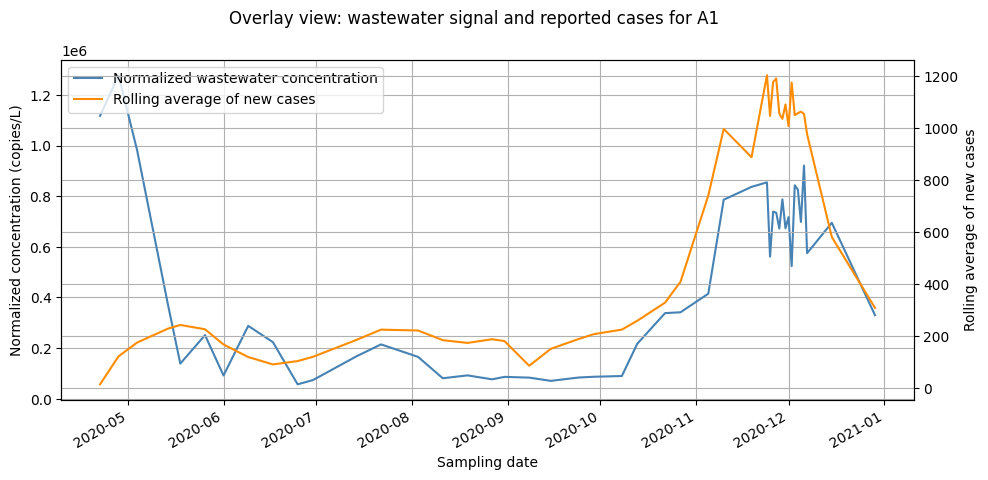

In [ ]:
if "label_dropdown" in globals():
    selected_label = label_dropdown.value
else:
    selected_label = sorted(df["fig1_label"].dropna().unique().tolist())[0]

plot_overlay_for_label(df, selected_label)


## Discussion prompt

Use the time-series graphs and the overlay graph to evaluate whether wastewater monitoring appears useful for tracking community COVID-19 trends.

**In your response, address:**
- whether wastewater concentration and reported case counts move in a similar direction
- whether higher wastewater periods seem to line up with higher case counts
- whether wastewater might offer an earlier signal for community spread
- how this could help hospitals or public-health teams prepare
- one limitation or caution when interpreting these graphs

Write **3 to 5 sentences** and use evidence from your plots.


<!-- Combined into the previous discussion prompt to avoid repetition. -->


## 7. Simple prediction model

In this section, students explore a basic regression model.

### Goal
Use wastewater concentration to estimate the rolling average of new reported cases.

This is **not** a clinical forecast tool.  
It is a simple classroom model for pattern-finding and interpretation.

In [ ]:
model_df, x, y, slope, intercept, r2 = prepare_regression_model(df)
explain_regression_for_students(slope, intercept, r2)



### Regression Summary

**Model equation**

`predicted_cases = 0.000201 * normalized_conc_copies_per_L + 181.055`

**Model fit**

`R^2 = 0.048`

### How to Read This

- **Best-fit line:** This line summarizes the overall trend between wastewater and case counts.
- **Slope (0.000201):** For each 1-unit increase in normalized wastewater concentration, predicted cases change by about `0.000201` on average.
- **Intercept (181.055):** This is the baseline model prediction when wastewater concentration is 0.
- **R^2 (0.048):** This is how much variation in case counts the line explains (`0` = very weak, `1` = very strong).


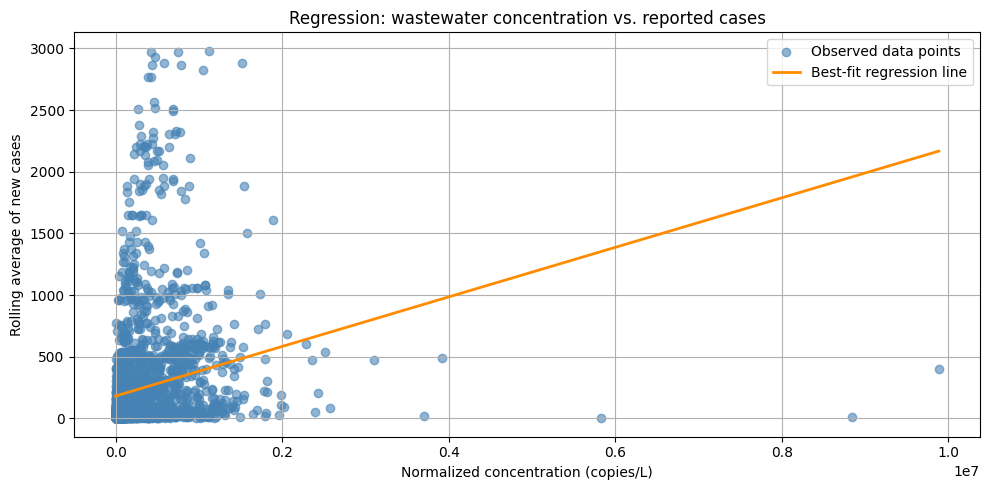


### How to Read This Graph

- **Blue dots:** each dot is one real observation from the dataset (wastewater level + reported cases).
- **Orange line:** this is the model's best-fit line showing the overall trend.
- **Upward slope:** if the line slopes up, higher wastewater values tend to go with higher reported case counts.
- **Distance from line:** dots far from the line show real-world noise and other factors not captured by this simple model.


In [ ]:
if not all(name in globals() for name in ["model_df", "slope", "intercept"]):
    model_df, x, y, slope, intercept, r2 = prepare_regression_model(df)

plot_regression_fit(model_df, slope, intercept)
explain_regression_plot_for_students()


## Final discussion

Use the regression graph and slider to answer the questions below.

1. What happens to predicted case counts when the wastewater signal increases?
2. How could hospitals or local health committees prepare if they start seeing those trends?
3. Does wastewater monitoring seem like a useful way to estimate case trends in a community?
4. What are some limits of this method?

Write 4 to 6 sentences.